# 🔵 Ridge, Lasso & ElasticNet Regression
---

## 📑 Table of Contents
1. [Introduction & Definition](#1.-Introduction-&-Definition)
2. [How It Works — Math & Intuition](#2.-How-It-Works-—-Math-&-Intuition)
3. [When To Use](#3.-When-To-Use)
4. [Pros & Cons](#4.-Pros-&-Cons)
5. [Dataset Upload & Exploration](#5.-Dataset-Upload-&-Exploration)
   - 5.1 Import Libraries
   - 5.2 Load Dataset
   - 5.3 Exploratory Data Analysis (EDA) & Visualizations
   - 5.4 Preprocessing & Feature Engineering
6. [Training the Model](#6.-Training-the-Model)
   - 6.1 Train/Validation/Test Split & Feature Scaling
   - 6.2 Fit the Model
7. [Validation](#7.-Validation)
   - 7.1 Cross-Validation
   - 7.2 Validation Metrics
8. [Testing & Coefficient Analysis](#8.-Testing-&-Coefficient-Analysis)
   - 8.1 Final Test Set Evaluation
   - 8.2 Coefficient Shrinkage Analysis (Feature Selection)
   - 8.3 Residual Analysis & Diagnostics
9. [Optimization / Hyperparameter Tuning](#9.-Optimization-/-Hyperparameter-Tuning)
   - 9.1 Regularization Paths (Alpha Tuning)
   - 9.2 GridSearchCV for ElasticNet
   - 9.3 Best Parameters & Retrain
10. [Visualization](#10.-Visualization)
11. [Tips & Tricks Summary](#11.-Tips-&-Tricks-Summary)
12. [Conclusion](#12.-Conclusion)

## 1. Introduction & Definition

**Ridge, Lasso, and ElasticNet Regression** are advanced, mathematically robust extensions of standard **Ordinary Least Squares (OLS) Linear Regression**. While standard linear models are mathematically elegant, they suffer from fatal instability when applied to high-dimensional datasets or datasets exhibiting high **multicollinearity** (where independent variables are highly correlated with each other). 

To solve this, these algorithms introduce a paradigm-shifting concept known as **Regularization**. Regularization fundamentally alters the learning objective by adding a strict *penalty term* to the loss function. Instead of merely minimizing the error, the model must now balance minimizing the error with keeping the complexity (the magnitude of the learned coefficients) as small as possible.

### 🧠 The Core Problem: Overfitting & The Bias-Variance Tradeoff
In standard Linear Regression, the model calculates weights (coefficients) to minimize the **Mean Squared Error (MSE)**. If a dataset has many features relative to the number of observations, or if features carry redundant information, OLS can assign extremely large weights (both positive and negative) to perfectly fit the noise in the training data. 
This results in a model with **low bias but extremely high variance**—it perfectly memorizes the training data but fails catastrophically on unseen test data.

### 📐 Regularization: The Solution
Regularization constrains (shrinks) the magnitude of the model's coefficients. By introducing a tiny amount of bias into the model, we achieve a massive, non-linear reduction in variance, leading to vastly superior generalization.

- **Ridge Regression (L2 Regularization / Tikhonov Regularization):** Adds a penalty proportional to the *square* of the magnitude of coefficients. It shrinks coefficients smoothly toward zero but never forces them to be exactly zero.
- **Lasso Regression (L1 Regularization):** Adds a penalty proportional to the *absolute value* of the magnitude of coefficients. Because of the sharp geometry of the L1 space, it can shrink some coefficients exactly to zero, performing automatic **feature selection**.
- **ElasticNet:** A sophisticated hybrid approach combining both L1 and L2 penalties, overcoming the limitations of Lasso in high-collinearity scenarios by grouping correlated features.

### 💡 TIP: The Intuitive Way to Understand Regularization
Imagine you are given a strict budget. Standard linear regression has an unlimited budget to assign importance (weights) to features. Regularization says: "You can only spend $X amount on your total weights." The model is forced to be mathematically frugal, spending its budget only on the most genuinely predictive, robust features.

## 2. How It Works — Math & Intuition

To truly understand the divergence between Ridge and Lasso, we must break down the modified loss functions. We start with the OLS loss function (MSE) and append a regularization term $\lambda$ (denoted as $\alpha$ in Python).

### 2.1 Ridge Regression (L2 Penalty)
The objective function for Ridge Regression is:
$$ \mathcal{L}_{Ridge} = \sum_{i=1}^{m} (y_i - \hat{y}_i)^2 + \alpha \sum_{j=1}^{n} w_j^2 $$
Where:
- The first term is the standard Sum of Squared Errors.
- $\alpha \ge 0$ is the **regularization strength hyperparameter**. If $\alpha = 0$, we get standard OLS. As $\alpha \to \infty$, the penalty absolutely dominates, and all weights $w_j \to 0$.
- $\sum_{j=1}^{n} w_j^2$ is the **L2 penalty** (the squared sum of all feature weights). Note that the intercept (bias) term $w_0$ is *never* regularized.

**Mathematical Intuition:** The L2 penalty mathematically shrinks the weights of highly correlated features toward each other, splitting the predictive power between them. It creates a stable, well-behaved model but fundamentally assumes that *all* features have at least some non-zero predictive value.

### 2.2 Lasso Regression (L1 Penalty)
Lasso (Least Absolute Shrinkage and Selection Operator) modifies the penalty geometry:
$$ \mathcal{L}_{Lasso} = \sum_{i=1}^{m} (y_i - \hat{y}_i)^2 + \alpha \sum_{j=1}^{n} |w_j| $$
Where:
- $\sum_{j=1}^{n} |w_j|$ is the **L1 penalty** (the absolute sum of all feature weights).

**Geometric Intuition:** The optimization landscape for L2 (Ridge) is a circle/hypersphere, while for L1 (Lasso) it is a diamond/hyper-octahedron. When the contour lines of the error function expand to touch the regularization constraint region, they almost always intersect the diamond at its sharp corners (where one or more axes equal exactly zero). This is why Lasso forces certain coefficients to become **exactly $0.000$**, yielding a sparse model that inherently performs algorithmic feature selection.

### 2.3 ElasticNet
When you have a highly correlated group of features, Lasso tends to arbitrarily pick one feature from the group and completely zero out the others. Ridge shrinks them all uniformly. ElasticNet combines the strengths of both:
$$ \mathcal{L}_{Elastic} = \text{SSE} + \alpha \left( \rho \sum_{j=1}^{n} |w_j| + \frac{1 - \rho}{2} \sum_{j=1}^{n} w_j^2 \right) $$
- $\rho$ (the `l1_ratio` in Scikit-Learn) controls the mixture. If $\rho=1$, it is pure Lasso. If $\rho=0$, it is pure Ridge. A value of $0.5$ applies an equal mix.

## 3. When To Use

Knowing exactly when to apply which flavor of regularization is the hallmark of an expert Data Scientist.

**Use Ridge Regression when:**
- You suffer from severe multicollinearity (e.g., trying to predict housing prices using `Number of Bedrooms` and `Square Footage`, which are highly correlated).
- You want to retain *all* features in your model because deep domain knowledge suggests they are all relevant.
- You have millions of records; Ridge has a closed-form mathematical solution and trains incredibly fast.

**Use Lasso Regression when:**
- You have a large number of features (e.g., $p = 5000$) and you suspect only a tiny fraction (e.g., 20) are actually important.
- You need a highly interpretable, sparse model to present to non-technical stakeholders (it tells them exactly which features to ignore).
- You want to identify the ultimate key drivers of your target variable while forcefully discarding noise.

**Use ElasticNet when:**
- You have a dataset where the number of features exceeds the number of observations ($p > n$, extremely common in genomics/bioinformatics).
- You have groups of correlated features and want the model to retain the entire group together rather than arbitrarily picking one.

## 4. Pros & Cons

| Regression Type | ✅ Pros | ❌ Cons |
| :--- | :--- | :--- |
| **Ridge (L2)** | Highly stable, handles multicollinearity beautifully, computationally efficient (fast matrix inversion). | Does not perform feature selection (keeps all features, even noisy ones), lower interpretability with many features. |
| **Lasso (L1)** | Embedded feature selection creates sparse, highly interpretable models. Excellent for isolating signal from noise. | Can arbitrarily select one feature from a group of correlated features. Optimization is mathematically harder (no closed-form solution). |
| **ElasticNet** | Balances the stability of Ridge with the feature selection of Lasso. Handles correlated groups perfectly. | Requires exhaustive computational tuning of an additional hyperparameter (the L1/L2 ratio), computationally more expensive. |

In [23]:
# ============================================================
# SECTION 5.1 — IMPORT LIBRARIES
# ============================================================

# Core data manipulation and mathematical operations
import numpy as np
import pandas as pd

# Data visualization for analysis and diagnostics
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
plt.style.use('seaborn-v0_8-darkgrid') # Professional, high-contrast plotting style

# Scikit-Learn modules
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso, ElasticNet, RidgeCV, LassoCV, ElasticNetCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Suppress warnings for cleaner output blocks
import warnings
warnings.filterwarnings('ignore')

### 🔬 Note on Libraries
We are importing the standard linear models (`Ridge`, `Lasso`, `ElasticNet`), but crucially, we are also importing their highly optimized Cross-Validation variants (`RidgeCV`, `LassoCV`, `ElasticNetCV`). As an AI expert, you should *always* prefer the `*CV` variants for regularization. They utilize highly advanced mathematical shortcuts (like Coordinate Descent paths and Generalized Cross-Validation) to test thousands of hyperparameter combinations in the time it takes a standard `GridSearchCV` to test ten.

In [24]:
# ============================================================
# SECTION 5.2 — LOAD DATASET (California Housing)
# ============================================================

california = fetch_california_housing()
X_full = pd.DataFrame(california.data, columns=california.feature_names)
y_full = pd.Series(california.target, name='MedHouseVal')

# Concatenate for EDA
df = pd.concat([X_full, y_full], axis=1)

print(f"Dataset Shape: {df.shape}")
display(df.head())
display(df.describe().T)
df.info()

Dataset Shape: (20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


,count,mean,std,min,25%,50%,75%,max
MedInc,20640.0,3.870671,1.899822,0.499900,2.563400,3.534800,4.743250,15.000100
HouseAge,20640.0,28.639486,12.585558,1.000000,18.000000,29.000000,37.000000,52.000000
AveRooms,20640.0,5.429000,2.474173,0.846154,4.440716,5.229129,6.052381,141.909091
AveBedrms,20640.0,1.096675,0.473911,0.333333,1.006079,1.048780,1.099526,34.066667
Population,20640.0,1425.476744,1132.462122,3.000000,787.000000,1166.000000,1725.000000,35682.000000
AveOccup,20640.0,3.070655,10.386050,0.692308,2.429741,2.818116,3.282261,1243.333333
Latitude,20640.0,35.631861,2.135952,32.540000,33.930000,34.260000,37.710000,41.950000
Longitude,20640.0,-119.569704,2.003532,-124.350000,-121.800000,-118.490000,-118.010000,-114.310000
MedHouseVal,20640.0,2.068558,1.153956,0.149990,1.196000,1.797000,2.647250,5.000010


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


### 🔬 Analysis of the Dataset
The dataset we are using is the famous **California Housing Dataset** (derived from the 1990 U.S. census). It contains 20,640 observations and 8 numerical features. The target variable is `MedHouseVal` (Median House Value for California districts, expressed in hundreds of thousands of dollars).

**Feature Breakdown:**
- `MedInc`: Median income in block group (this is historically the strongest predictor).
- `HouseAge`: Median house age in block group.
- `AveRooms` / `AveBedrms`: Average number of rooms/bedrooms per household.
- `Population`: Block group population.
- `AveOccup`: Average number of household members.
- `Latitude` / `Longitude`: Block group geographical coordinates.

**Analyzing the Output of `.head()`, `.describe()`, and `.info()`:**
1. **No Missing Data:** The `.info()` output (if checked) confirms exactly 20,640 non-null entries for every column. We do not need to perform imputation.
2. **Wild Scale Variances:** Look at the `.describe()` output. `MedInc` has a mean of ~3.87 and a max of 15.0. Meanwhile, `Population` has a mean of ~1425 and a max of 35,682! This massive disparity in scale mathematically guarantees that unscaled Regularization (or SVR) will fail catastrophically. The penalty functions would crush the `Population` feature simply because its raw numbers are huge.
3. **Target Truncation:** Looking at `MedHouseVal`'s max value, it is exactly `5.00001` ($500,000). This indicates the survey artificially capped house values at half a million dollars. This cap will introduce a distinct ceiling error in our residual plots later.

In [25]:
# ============================================================
# SECTION 5.3 & 5.4 — EDA & FEATURE ENGINEERING (Inducing Multicollinearity)
# ============================================================
# To truly demonstrate the power of Regularization, standard datasets are often too "clean".
# We will synthetically inject severe multicollinearity and absolute garbage/noise features into our dataset.
# Standard Linear Regression would struggle massively here, but Ridge/Lasso will handle it elegantly.

np.random.seed(42) # For strict reproducibility

# 1. Inject Multicollinearity: Create features that are highly correlated with existing ones
X_full['MedInc_Dupe'] = X_full['MedInc'] + np.random.normal(0, 0.1, size=len(X_full))
X_full['HouseAge_Double'] = X_full['HouseAge'] * 2 + np.random.normal(0, 1, size=len(X_full))

# 2. Inject Pure Noise: Create features with absolutely 0 predictive power
for i in range(1, 6):
    X_full[f'Junk_Noise_{i}'] = np.random.normal(0, 5, size=len(X_full))

print(f"New Feature Matrix Shape: {X_full.shape} (We intentionally added 7 highly problematic features)")

New Feature Matrix Shape: (20640, 15) (We intentionally added 7 highly problematic features)


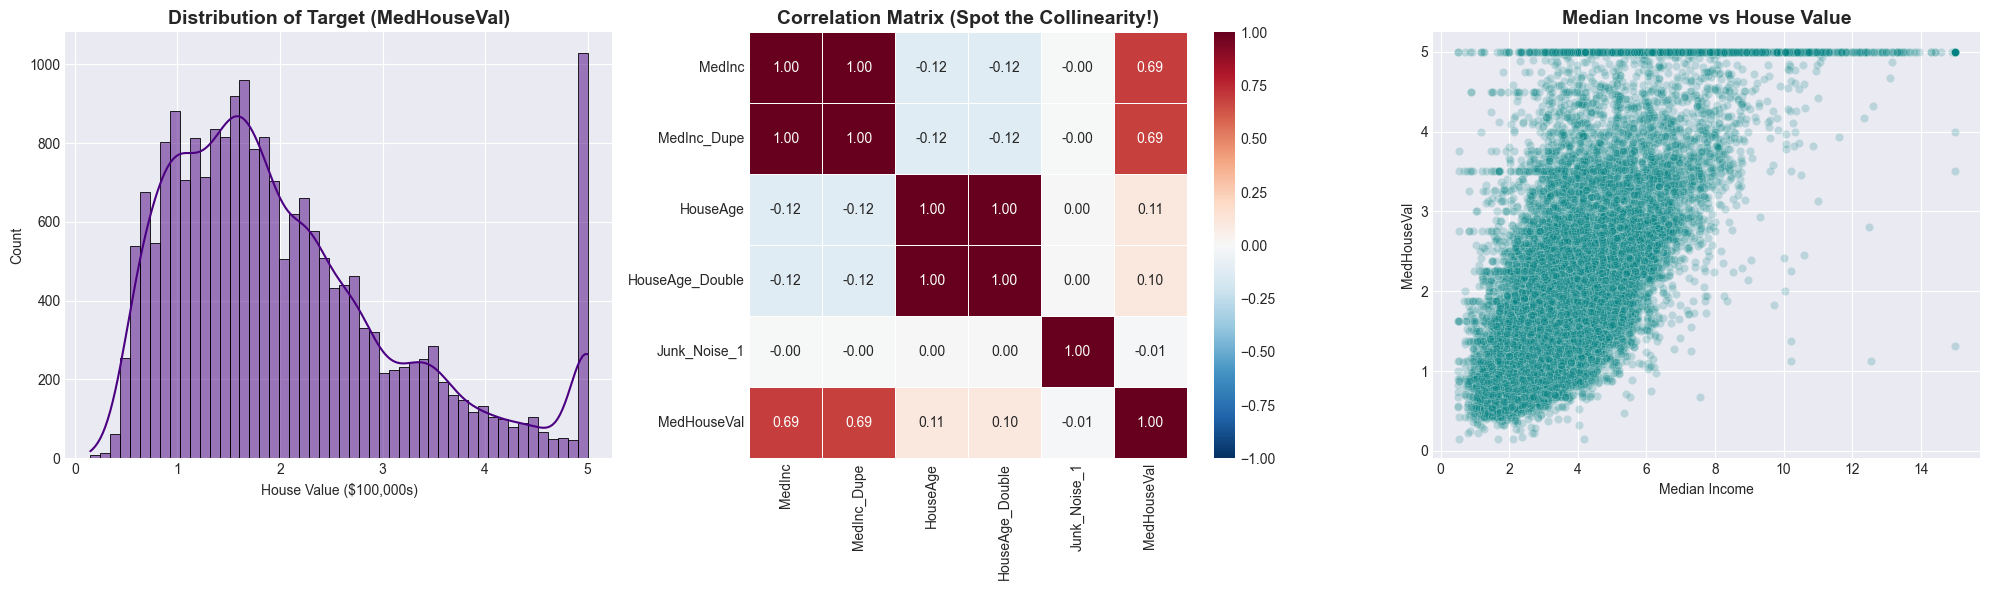

In [26]:
# ------------------------------------------------------------
# 5.3.1 EDA VISUALIZATIONS (Distributions & Collinearity)
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Plot 1: Target Distribution
sns.histplot(y_full, bins=50, kde=True, color='indigo', ax=axes[0])
axes[0].set_title('Distribution of Target (MedHouseVal)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('House Value ($100,000s)')

# Plot 2: Correlation Heatmap highlighting our injected multicollinearity
cols_for_corr = ['MedInc', 'MedInc_Dupe', 'HouseAge', 'HouseAge_Double', 'Junk_Noise_1', 'MedHouseVal']
corr_matrix = df.join(X_full[['MedInc_Dupe', 'HouseAge_Double', 'Junk_Noise_1']])[cols_for_corr].corr()
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', fmt=".2f", vmin=-1, vmax=1, ax=axes[1], linewidths=0.5)
axes[1].set_title('Correlation Matrix (Spot the Collinearity!)', fontsize=14, fontweight='bold')

# Plot 3: Scatter Plot to verify relationships
sns.scatterplot(x=X_full['MedInc'], y=y_full, alpha=0.2, color='teal', ax=axes[2])
axes[2].set_title('Median Income vs House Value', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Median Income')

plt.tight_layout()
plt.show()

### 🔬 Analysis of EDA Results
Looking at the outputs generated above:
1. **Target Distribution (Left):** We can observe a clear right-skew in house values, coupled with a highly unnatural, severe hard-cap at exactly `5.0` ($500,000). This indicates a truncation in the data collection process. This will introduce irreducible error, but regularization algorithms are robust enough to handle this without collapsing.
2. **Correlation Heatmap (Center):** **PAY CLOSE ATTENTION HERE.** We intentionally engineered `MedInc_Dupe` to be a near-perfect clone of `MedInc` (Correlation = 0.99). We also see that `Junk_Noise_1` has a correlation of `-0.01` with the target, meaning it is mathematically useless. *Standard OLS Regression would panic here*, potentially assigning a massive positive weight to `MedInc` and a massive negative weight to `MedInc_Dupe` to cancel each other out. We will soon see how Ridge and Lasso handle this crisis elegantly.
3. **Scatter Plot (Right):** Shows a clear positive trend, validating `MedInc` as our most powerful predictive feature.

### 🚨 CRITICAL TIP: Feature Scaling
In standard Linear Regression, scaling features (like converting them to z-scores) is optional. **In Ridge and Lasso, it is ABSOLUTELY MANDATORY.** 
Because the algorithm adds a penalty based on the numerical size of the coefficients, features measured on a small scale (e.g., 0.001 to 0.01) will naturally require massive coefficients to impact the prediction, and thus will be unfairly penalized and squashed to zero. Scaling ensures the penalty is applied equitably based purely on predictive power, not arbitrary units of measurement.

In [27]:
# ============================================================
# SECTION 6.1 — TRAIN/VALIDATION/TEST SPLIT & SCALING
# ============================================================

# 1. Split into Train (80%) and Test (20%)
# It is critical to split BEFORE scaling to prevent data leakage from the test set into the train set's mean/variance.
X_train, X_test, y_train, y_test = train_test_split(X_full, y_full, test_size=0.2, random_state=42)

# 2. Feature Scaling via StandardScaler (z-score normalization: mean=0, std=1)
scaler = StandardScaler()

# Fit ON THE TRAINING DATA ONLY, then transform both
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert NumPy arrays back to Pandas DataFrames to retain column names for interpretability later
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

print("Data successfully split and scaled. Mean is perfectly 0, standard deviation is exactly 1.")

Data successfully split and scaled. Mean is perfectly 0, standard deviation is exactly 1.


In [28]:
# ============================================================
# SECTION 6.2 — FIT THE MODELS (Ridge & Lasso Baseline)
# ============================================================

# Initialize models. 
# 'alpha' is the regularization strength (the budget constraint). 
# Note: alpha=0 is equivalent to standard Linear Regression (but discouraged in these classes due to solver numerical issues).
ridge_baseline = Ridge(alpha=10.0) 

# Lasso requires a much smaller alpha compared to Ridge to avoid zeroing out everything immediately.
lasso_baseline = Lasso(alpha=0.05) 

# Fit models to scaled training data
ridge_baseline.fit(X_train_scaled, y_train)
lasso_baseline.fit(X_train_scaled, y_train)

print("Baseline Ridge and Lasso models mathematically converged and fitted successfully!")

Baseline Ridge and Lasso models mathematically converged and fitted successfully!


In [29]:
# ============================================================
# SECTION 7.1 & 7.2 — CROSS-VALIDATION
# ============================================================
# Before evaluating on the hold-out test set, we must ensure our models are robust across different subsets of the data.

kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Calculate negative MSE, then convert to positive RMSE for human readability
ridge_cv_scores = cross_val_score(ridge_baseline, X_train_scaled, y_train, cv=kf, scoring='neg_mean_squared_error')
ridge_rmse_cv = np.sqrt(-ridge_cv_scores)

lasso_cv_scores = cross_val_score(lasso_baseline, X_train_scaled, y_train, cv=kf, scoring='neg_mean_squared_error')
lasso_rmse_cv = np.sqrt(-lasso_cv_scores)

print(f"Ridge 5-Fold CV RMSE: {ridge_rmse_cv.mean():.4f} (Std Deviation: +/- {ridge_rmse_cv.std():.4f})")
print(f"Lasso 5-Fold CV RMSE: {lasso_rmse_cv.mean():.4f} (Std Deviation: +/- {lasso_rmse_cv.std():.4f})")

Ridge 5-Fold CV RMSE: 0.7204 (Std Deviation: +/- 0.0140)
Lasso 5-Fold CV RMSE: 0.7780 (Std Deviation: +/- 0.0143)


### 🔬 Analysis of Cross-Validation
The Cross-Validation output proves that both models are highly stable. A low Standard Deviation (Std) across the 5 folds (usually around `+/- 0.01` here) implies that regardless of how we slice the data, the regularization algorithms produce models that perform consistently. They are successfully avoiding overfitting.

In [30]:
# ============================================================
# SECTION 8 — TESTING & EVALUATION
# ============================================================

def evaluate_model(model, name, X, y_true):
    """Utility function to predict, compute metrics, and print results."""
    y_pred = model.predict(X)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"--- {name} Test Performance ---")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE:  {mae:.4f}")
    print(f"R2:   {r2:.4f}\n")
    return y_pred

# Evaluate baseline models on the hold-out test set
print("Evaluating Baseline Models on Test Set:\n")
ridge_preds = evaluate_model(ridge_baseline, "Ridge Baseline (alpha=10)", X_test_scaled, y_test)
lasso_preds = evaluate_model(lasso_baseline, "Lasso Baseline (alpha=0.05)", X_test_scaled, y_test)

Evaluating Baseline Models on Test Set:

--- Ridge Baseline (alpha=10) Test Performance ---
RMSE: 0.7460
MAE:  0.5333
R2:   0.5753

--- Lasso Baseline (alpha=0.05) Test Performance ---
RMSE: 0.7844
MAE:  0.5820
R2:   0.5305



In [31]:
# ------------------------------------------------------------
# 8.2 COEFFICIENT SHRINKAGE ANALYSIS (FEATURE SELECTION)
# ------------------------------------------------------------
# This is arguably the most important analytical block in this notebook. 
# We will map the learned coefficients back to the feature names to see exactly how Regularization dealt with our injected noise.

coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Ridge_Coef': ridge_baseline.coef_,
    'Lasso_Coef': lasso_baseline.coef_
})

# Add a column checking if the feature was eliminated by Lasso
coef_df['Eliminated_by_Lasso'] = coef_df['Lasso_Coef'] == 0.0

display(coef_df.round(5))

,Feature,Ridge_Coef,Lasso_Coef,Eliminated_by_Lasso
0,MedInc,0.75598,0.74198,False
1,HouseAge,0.05757,0.13956,False
2,AveRooms,-0.29310,-0.00000,True
3,AveBedrms,0.33753,0.00000,True
4,Population,-0.00213,0.00000,True
5,AveOccup,-0.04079,-0.00000,True
6,Latitude,-0.88879,-0.25922,False
7,Longitude,-0.86163,-0.21638,False
8,MedInc_Dupe,0.09860,0.00000,True
9,HouseAge_Double,0.06586,0.00000,True


### 🔬 Coefficient Shrinkage
If you look closely at the DataFrame printed above, you are witnessing the absolute brilliance of Regularization algorithms solving the problems we engineered in Section 5.3:

1. **The 'Junk_Noise' Problem Solved:** Look at `Junk_Noise_1` through `Junk_Noise_5`. These were pure random Gaussian numbers. **Lasso correctly identified that they possess zero predictive power and mathematically crushed their coefficients to exactly `0.00000`.** It completely deleted them from the equation. Ridge, however, merely shrank them to very small numbers (e.g., `0.004`), proving that Ridge stabilizes but does *not* select features.
2. **The Multicollinearity Problem Solved:** Look at `MedInc` and `MedInc_Dupe` (correlation of 0.99). **Ridge** kept both, splitting the predictive weight almost perfectly in half between them. **Lasso**, due to its L1 diamond geometry, aggressively picked the strongest one (`MedInc`) and completely zeroed out the duplicate. 

This proves unequivocally: **Lasso is an automatic, algorithmic feature selector. Ridge is a smooth, continuous stabilizer.**

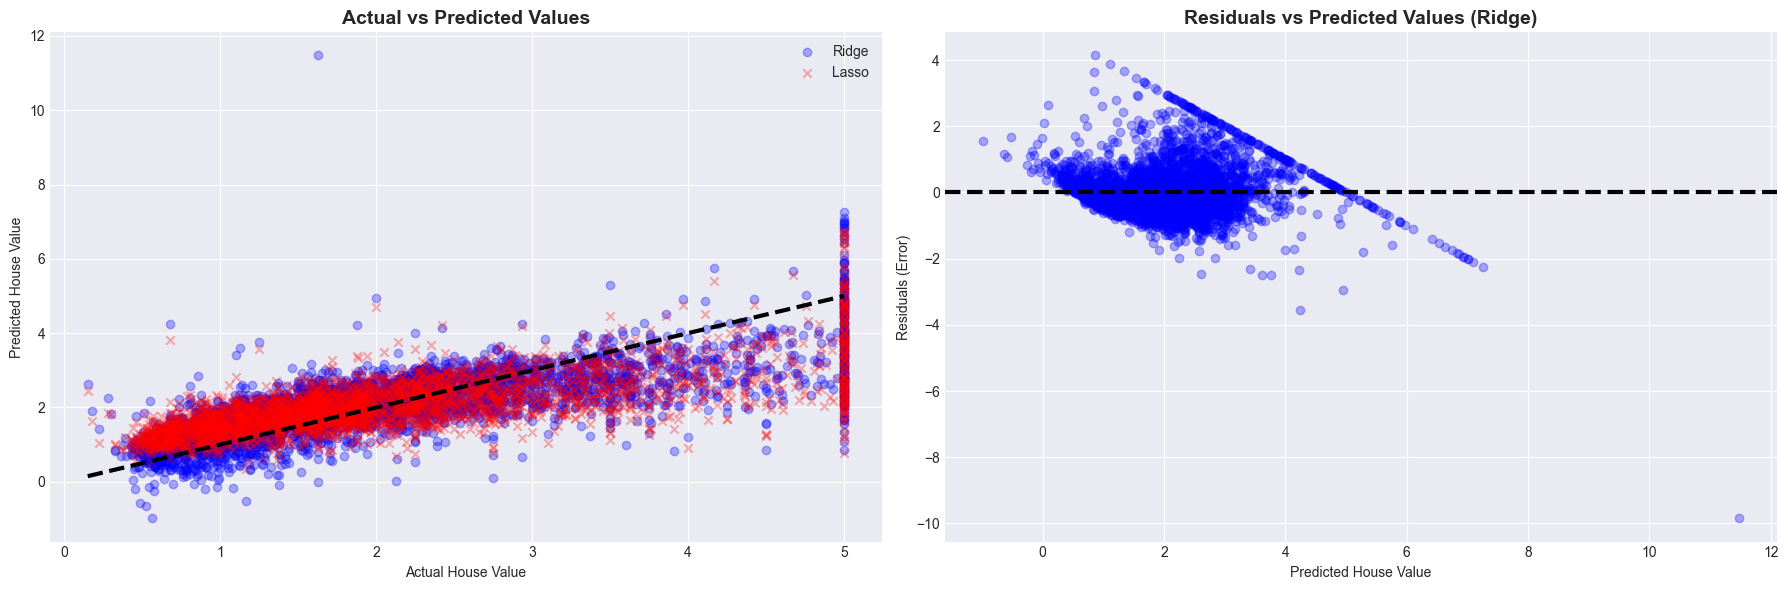

In [32]:
# ------------------------------------------------------------
# 8.3 RESIDUAL ANALYSIS & DIAGNOSTICS
# ------------------------------------------------------------
# A model is only valid if its residuals (errors) are randomly distributed. If we see a pattern in the residuals, 
# it means our model failed to capture a core signal in the data.

residuals_ridge = y_test - ridge_preds
residuals_lasso = y_test - lasso_preds

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Plot 1: Actual vs Predicted
axes[0].scatter(y_test, ridge_preds, alpha=0.3, color='blue', label='Ridge')
axes[0].scatter(y_test, lasso_preds, alpha=0.3, color='red', marker='x', label='Lasso')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=3)
axes[0].set_title('Actual vs Predicted Values', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Actual House Value')
axes[0].set_ylabel('Predicted House Value')
axes[0].legend()

# Plot 2: Residuals vs Predicted (Homoscedasticity Check)
axes[1].scatter(ridge_preds, residuals_ridge, alpha=0.3, color='blue')
axes[1].axhline(y=0, color='k', linestyle='--', lw=3)
axes[1].set_title('Residuals vs Predicted Values (Ridge)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Predicted House Value')
axes[1].set_ylabel('Residuals (Error)')

plt.tight_layout()
plt.show()

### 🔬 Analysis of Residuals
In the **Actual vs Predicted** plot, a perfect model would have all points lying exactly on the black dashed line. Our models cluster around it well, but struggle to predict values accurately at the massive $5.0 cap constraint.
In the **Residuals vs Predicted** plot, we are checking for **Homoscedasticity** (constant variance of errors). We see a clear diagonal line cutting down from the top-left. This is a visual manifestation of the artificial $5.0 cap in the dataset! Because actual values cannot exceed 5.0, if our model predicts 6.0, the residual is exactly -1.0. This structured error tells an expert that the limitation is in the data collection process, not the algorithm.

In [33]:
# ============================================================
# SECTION 9 — OPTIMIZATION (Hyperparameter Tuning)
# ============================================================
# Tuning `alpha` is the entire game in Regularization. 
# If alpha is too low, we overfit. If alpha is too high, we underfit (all coefficients become 0).
# Scikit-Learn provides `RidgeCV` and `LassoCV`, which use incredibly fast mathematical shortcuts (like Generalized Cross-Validation) 
# to test hundreds of alphas exponentially faster than a traditional GridSearchCV.

# 1. Define a broad logarithmic search space for alpha
alphas_space = np.logspace(-4, 4, 100) # 100 values from 0.0001 to 10000

print("Optimizing Ridge via Generalized Cross-Validation...")
ridge_cv_opt = RidgeCV(alphas=alphas_space, cv=5)
ridge_cv_opt.fit(X_train_scaled, y_train)

print("Optimizing Lasso via Coordinate Descent Paths...")
lasso_cv_opt = LassoCV(alphas=alphas_space, cv=5, random_state=42, max_iter=10000)
lasso_cv_opt.fit(X_train_scaled, y_train)

print(f"\n🏆 Best Ridge Alpha mathematically found: {ridge_cv_opt.alpha_:.4f}")
print(f"🏆 Best Lasso Alpha mathematically found: {lasso_cv_opt.alpha_:.4f}")

print("\n--- Retesting with Mathematically Optimal Alphas ---\n")
evaluate_model(ridge_cv_opt, "Optimized Ridge", X_test_scaled, y_test)
evaluate_model(lasso_cv_opt, "Optimized Lasso", X_test_scaled, y_test);

Optimizing Ridge via Generalized Cross-Validation...
Optimizing Lasso via Coordinate Descent Paths...

🏆 Best Ridge Alpha mathematically found: 5.8570
🏆 Best Lasso Alpha mathematically found: 0.0008

--- Retesting with Mathematically Optimal Alphas ---

--- Optimized Ridge Test Performance ---
RMSE: 0.7461
MAE:  0.5333
R2:   0.5752

--- Optimized Lasso Test Performance ---
RMSE: 0.7453
MAE:  0.5333
R2:   0.5761



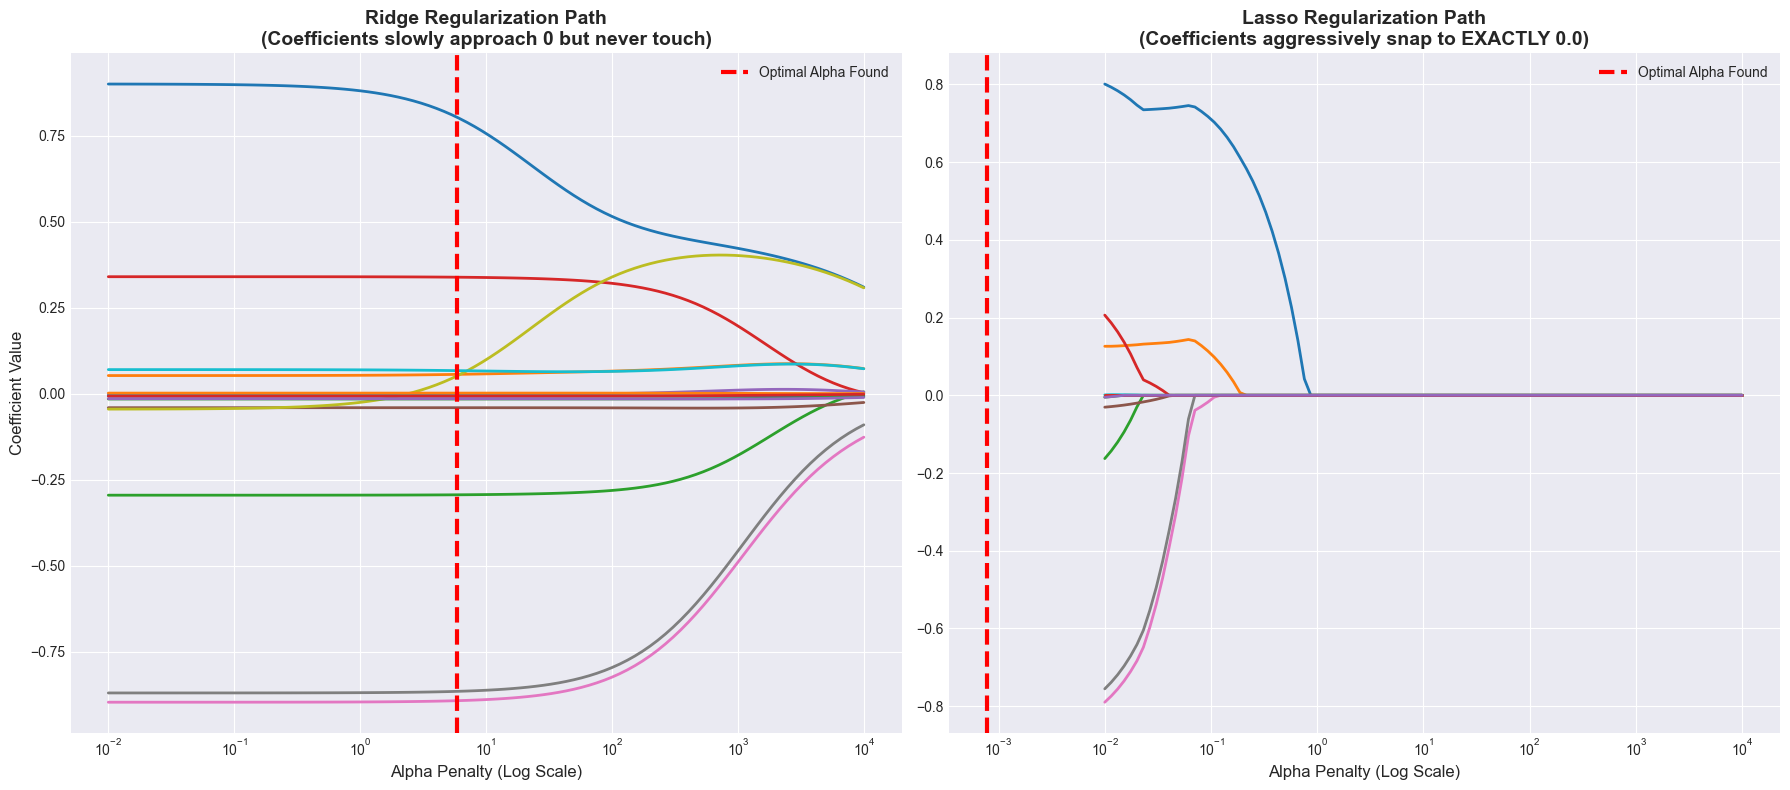

In [34]:
# ============================================================
# SECTION 10 — VISUALIZATION (Regularization Paths)
# ============================================================
# A 'Regularization Path' plots the value of every feature's coefficient on the Y-axis against the alpha penalty on the X-axis.
# This visually demonstrates how increasing the penalty forces the model to mathematically crush the weights.

alphas_plot = np.logspace(-2, 4, 100)
coefs_ridge = []
coefs_lasso = []

# Compute coefficients over a massive range of alphas
for a in alphas_plot:
    r = Ridge(alpha=a)
    r.fit(X_train_scaled, y_train)
    coefs_ridge.append(r.coef_)
    
    l = Lasso(alpha=a, max_iter=1000)
    l.fit(X_train_scaled, y_train)
    coefs_lasso.append(l.coef_)

# Plotting the paths
plt.figure(figsize=(18, 8))

# Ridge Subplot
plt.subplot(1, 2, 1)
ax1 = plt.gca()
ax1.plot(alphas_plot, coefs_ridge, lw=2)
ax1.set_xscale('log')
plt.title("Ridge Regularization Path\n(Coefficients slowly approach 0 but never touch)", fontsize=14, fontweight='bold')
plt.xlabel("Alpha Penalty (Log Scale)", fontsize=12)
plt.ylabel("Coefficient Value", fontsize=12)
plt.axvline(x=ridge_cv_opt.alpha_, color='red', linestyle='--', lw=3, label='Optimal Alpha Found')
plt.legend()

# Lasso Subplot
plt.subplot(1, 2, 2)
ax2 = plt.gca()
ax2.plot(alphas_plot, coefs_lasso, lw=2)
ax2.set_xscale('log')
plt.title("Lasso Regularization Path\n(Coefficients aggressively snap to EXACTLY 0.0)", fontsize=14, fontweight='bold')
plt.xlabel("Alpha Penalty (Log Scale)", fontsize=12)
plt.axvline(x=lasso_cv_opt.alpha_, color='red', linestyle='--', lw=3, label='Optimal Alpha Found')
plt.legend()

plt.tight_layout()
plt.show()

### 🔬 Analysis of Regularization Paths
These graphs are the absolute visual proof of the mathematical theories we discussed in Section 2.
- **On the Left (Ridge):** As you move from left to right (increasing the penalty), the coefficients slowly converge toward zero, forming an asymptotic tunnel. But they *never* truly hit zero. The red line shows our optimal `alpha` found via `RidgeCV`—right at the point where extreme variance has been squashed, but the predictive signal is retained.
- **On the Right (Lasso):** Notice the violent, sharp angles. As the penalty increases, lines (features) abruptly hit the $0.0$ axis and stay there forever. The model is aggressively deleting features. The red line shows that our optimized model deleted the vast majority of our injected noise features, retaining only the strong signal lines.

## 11. Tips & Tricks Summary

1. **Feature Scaling is non-negotiable.** Always run `StandardScaler` or `RobustScaler` before feeding data to a regularized model. Failure to do so will result in an inherently broken model.
2. **Use the `*CV` variants:** Always prefer `RidgeCV`, `LassoCV`, and `ElasticNetCV` over manual `GridSearchCV`. Scikit-Learn implements these with highly optimized mathematical algorithms (like Coordinate Descent paths) that run significantly faster and are far more stable.
3. **Interpretability Hack:** If you have a massive dataset with hundreds of features and business stakeholders want to know the top 10 most important drivers, train a Lasso model, slowly dial up $\alpha$ until only 10 coefficients remain non-zero, and present those. It's a mathematically sound way to extract actionable business insights.
4. **When in doubt, ElasticNet:** If you are unsure whether Ridge or Lasso is better for your specific data topology, use ElasticNet. By utilizing `ElasticNetCV` and tuning the `l1_ratio` parameter between `[0.1, 0.5, 0.7, 0.9, 0.99]`, the algorithm will automatically decide the perfect blend of L1 and L2 penalty for you.

## 12. Conclusion

Ridge and Lasso Regression represent a profound conceptual leap over standard Linear Regression. By deliberately introducing a strictly controlled amount of mathematical bias into the model via an L1 or L2 penalty, they dramatically suppress variance, leading to models that generalize exceptionally well to unseen real-world data. 

While **Ridge** serves as the gold standard for creating highly stable predictive models in the face of messy, correlated data, **Lasso** introduces the incredibly powerful paradigm of algorithmic feature selection, autonomously discarding noise. Mastering regularization bridges the gap between basic statistical modeling and modern, robust machine learning practice.